In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from models.cbm_discovery import ConceptDiscoveryModel   # <-- adjust to actual path
from data.tsregression import TSRegressionDataset
from torch.utils.data import DataLoader
from darts import TimeSeries

from sklearn.metrics import mean_squared_error

Procedure when loading new model:
- Find checkpoint in outputs dir specified during training
- Go to wandb.ai and extract config file, add n_tasks, input_dim, input_length and latent_dim to it.
- Make sure the .csv we specify later is the correct one for the model.

In [ ]:
def get_model_and_preds(ckpt_path: str, dataset: str, hparams_file: str):
    ckpt_path = ckpt_path
    data_path = "../datasets"
    dataset = dataset
    target_scaling = 1.0
    target_log = False
    subsampling = 1
    batch_size = 256

    # flattened config compatible with PyTorch Lightning, not the one directly from wandb.ai
    model = ConceptDiscoveryModel.load_from_checkpoint(ckpt_path, hparams_file=hparams_file) 

    test_ds = TSRegressionDataset(path=data_path, problem=dataset, mode="test", scaling="none", target_scaling=target_scaling, target_log=target_log, subsampling=subsampling)
    test_dl = DataLoader(test_ds, batch_size=batch_size, num_workers=8, shuffle=False, drop_last=False)

    predictions = []

    with torch.no_grad():
        for batch in test_dl:
            # tuple-style batch: (x, y) or (x, y, c)
            x = batch[0].to(model.device)
            out = model(x)
            predictions.append(out["y_pred"].cpu())

    predictions = torch.cat(predictions, dim=0)
    print(predictions.shape)

    return predictions

In [6]:
predictions1 = get_model_and_preds("../outputs/checkpoints/last.ckpt", "VeasExtendedPilotData1", "config1.yaml")
predictions2 = get_model_and_preds("../outputs/checkpoints/last-v1.ckpt", "VeasExtendedPilotData2", "config2.yaml")

32304it [00:12, 2544.95it/s]


Minimum length: 48
Reshaping data


100%|██████████| 32298/32298 [00:10<00:00, 2976.92it/s]


torch.Size([32298, 1])


27220it [00:09, 2726.62it/s]


Minimum length: 48
Reshaping data


100%|██████████| 27214/27214 [00:07<00:00, 3812.53it/s]


torch.Size([27214, 1])


In [10]:
def convert_preds_to_timeseries(data_csv: str, predictions: torch.Tensor) -> TimeSeries:
    # Process predictions and ground truth data into TimeSeries for visualization
    df = pd.read_csv(data_csv)

    df["time"] = pd.to_datetime(df["Time"])

    # Calculate the correct test split start index based on process_csv_data_into_ts.py
    WINDOW = 48
    HORIZON = 12
    TRAIN_RATIO = 0.8

    N = len(df)
    num_samples = N - WINDOW - HORIZON + 1
    n_train = int(num_samples * TRAIN_RATIO)

    # The target for the first test sample is shifted by the window and horizon
    test_start_index = n_train + WINDOW + HORIZON - 1

    df = df.iloc[test_start_index:]
    time_values = df["time"].values

    print(f"Time values length: {len(time_values)}")
    print(f"Predictions length: {len(predictions)}")

    # Convert predictions to TimeSeries
    magnets_pred = TimeSeries.from_times_and_values(
        times=pd.to_datetime(time_values),
        values=predictions.numpy(),
        freq="5min",
        
    ).astype(np.float32)

    return magnets_pred

In [11]:
magnets_pred1 = convert_preds_to_timeseries("../veas_extended_pilot_data.csv", predictions1)
magnets_pred2 = convert_preds_to_timeseries("../veas_extended_pilot_data_2024.csv", predictions2)

Time values length: 32298
Predictions length: 32298
Time values length: 27214
Predictions length: 27214


In [15]:
def get_other_model_preds(preds_csv: str) -> tuple:
    # Read the CSV file
    df = pd.read_csv(preds_csv)
    df["time"] = pd.to_datetime(df["time"])

    # Extract first and second columns as numpy arrays with names from headers
    ground_truth = TimeSeries.from_dataframe(df, time_col="time", value_cols="ground_truth", freq="5min", fill_missing_dates=True).astype(np.float32)
    nc_rnn = TimeSeries.from_dataframe(df, time_col="time", value_cols="nc_rnn", freq="5min", fill_missing_dates=True).astype(np.float32)
    nc_tcn = TimeSeries.from_dataframe(df, time_col="time", value_cols="nc_tcn", freq="5min", fill_missing_dates=True).astype(np.float32)
    nc_xgboost = TimeSeries.from_dataframe(df, time_col="time", value_cols="nc_xgboost", freq="5min", fill_missing_dates=True).astype(np.float32)
    nc_elasticnet = TimeSeries.from_dataframe(df, time_col="time", value_cols="nc_elasticnet", freq="5min", fill_missing_dates=True).astype(np.float32)

    return ground_truth, nc_rnn, nc_tcn, nc_xgboost, nc_elasticnet

In [16]:
ground_truth1, nc_rnn1, nc_tcn1, nc_xgboost1, nc_elasticnet1 = get_other_model_preds('../datasets/VeasExtendedPilotData1/sommer2025_eivinds_configs_preds_nc_only.csv')
ground_truth2, nc_rnn2, nc_tcn2, nc_xgboost2, nc_elasticnet2 = get_other_model_preds('../datasets/VeasExtendedPilotData2/sommer2025_eivinds_configs_preds.csv')

In [18]:
def plot_preds_and_ground_truth(ground_truth, nc_rnn, nc_tcn, nc_xgboost, nc_elasticnet, magnets_pred):
    plt.figure(figsize=(15, 7))
    ground_truth.plot(label="Ground Truth Darts", color='gray')
    nc_rnn.plot(label="Nowcast RNN", color="r", alpha=0.7)
    plt.show()

    plt.figure(figsize=(15, 7))
    ground_truth.plot(label="Ground Truth Darts", color='gray')
    nc_tcn.plot(label="Nowcast TCN", color="orange", alpha=0.7)
    plt.show()

    plt.figure(figsize=(15, 7))
    ground_truth.plot(label="Ground Truth Darts", color='gray')
    nc_xgboost.plot(label="Nowcast XGBoost", color="green", alpha=0.7)
    plt.show()

    plt.figure(figsize=(15, 7))
    ground_truth.plot(label="Ground Truth Darts", color='gray')
    nc_elasticnet.plot(label="Nowcast ElasticNet", color="purple", alpha=0.7)
    plt.show()

    plt.figure(figsize=(15, 7))
    ground_truth.plot(label="Ground Truth Darts", color='gray')
    magnets_pred.plot(label="MAGNETS", color="b", alpha=0.7)
    plt.show()

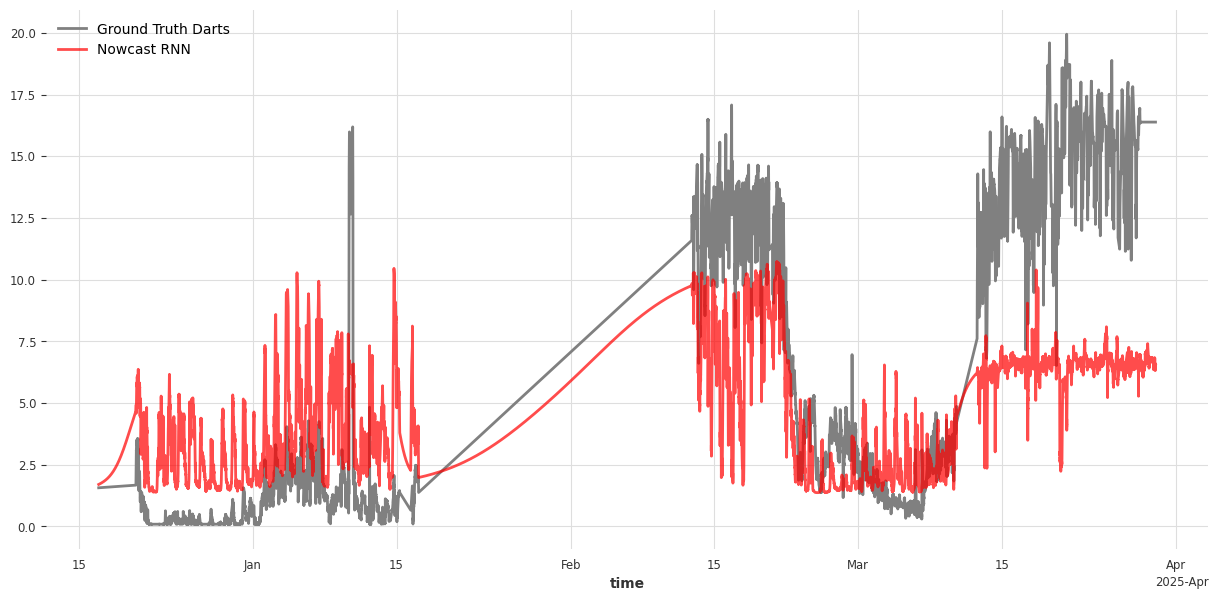

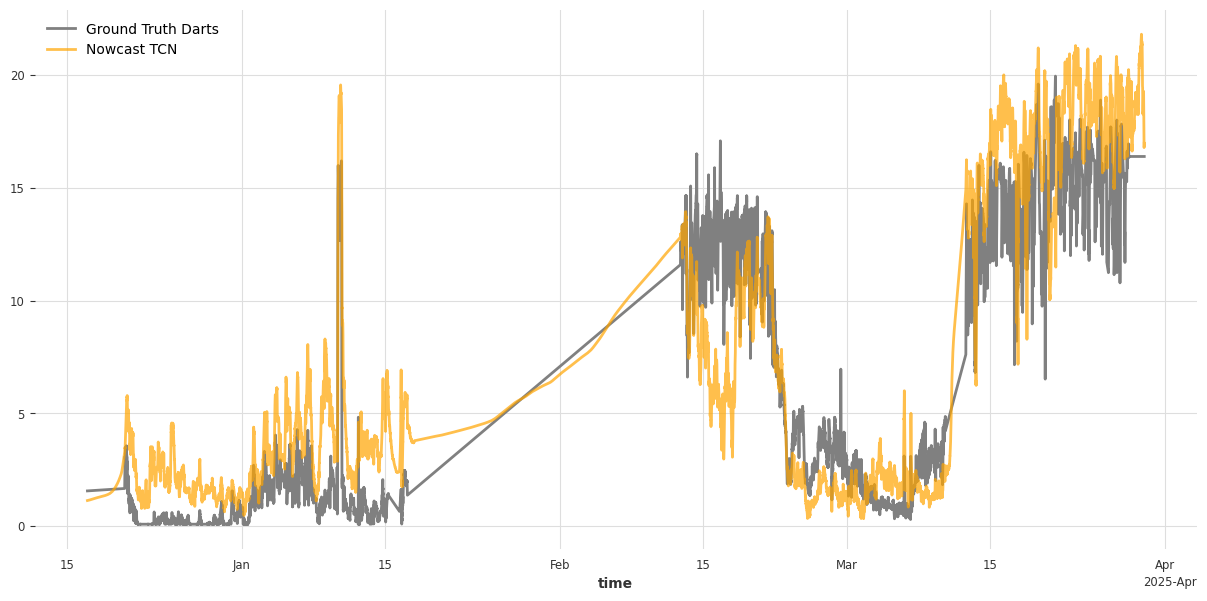

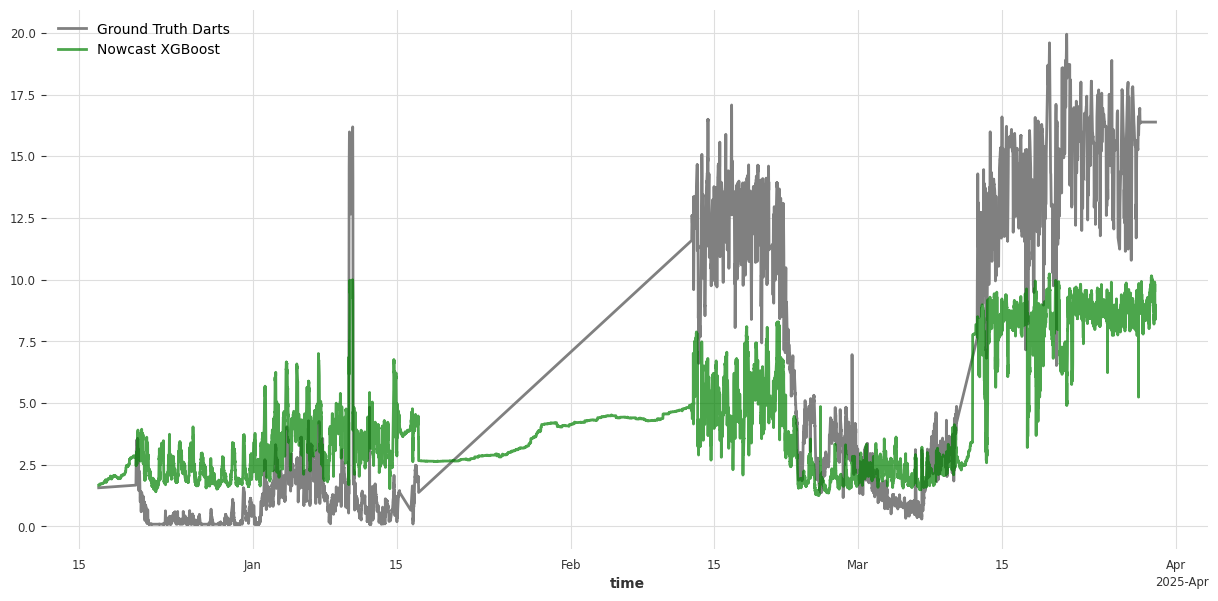

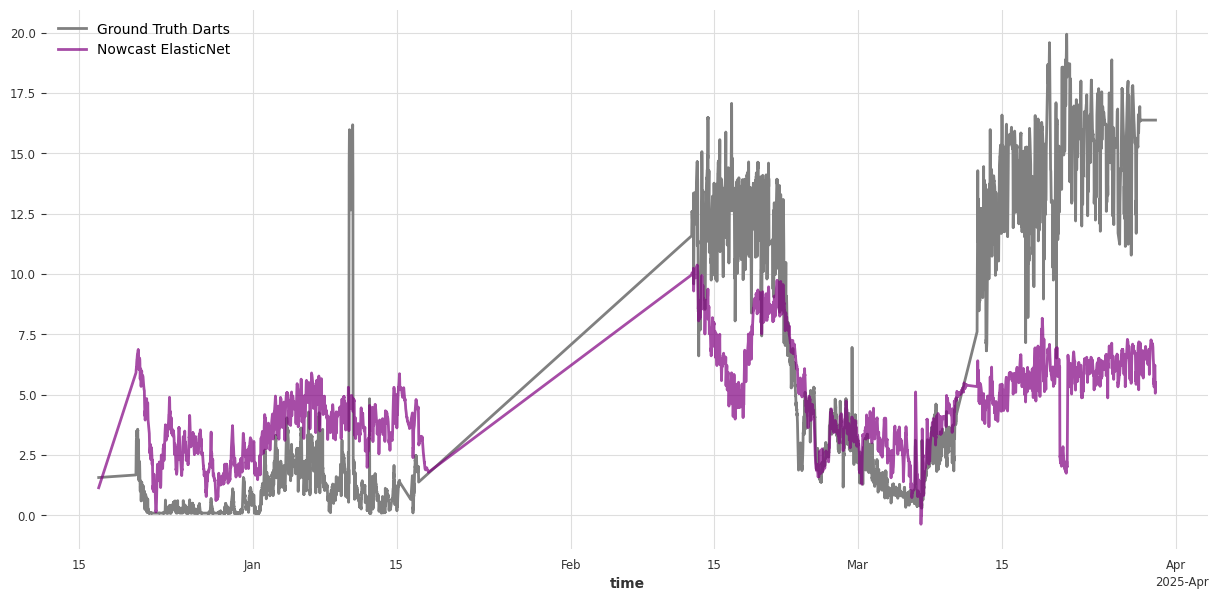

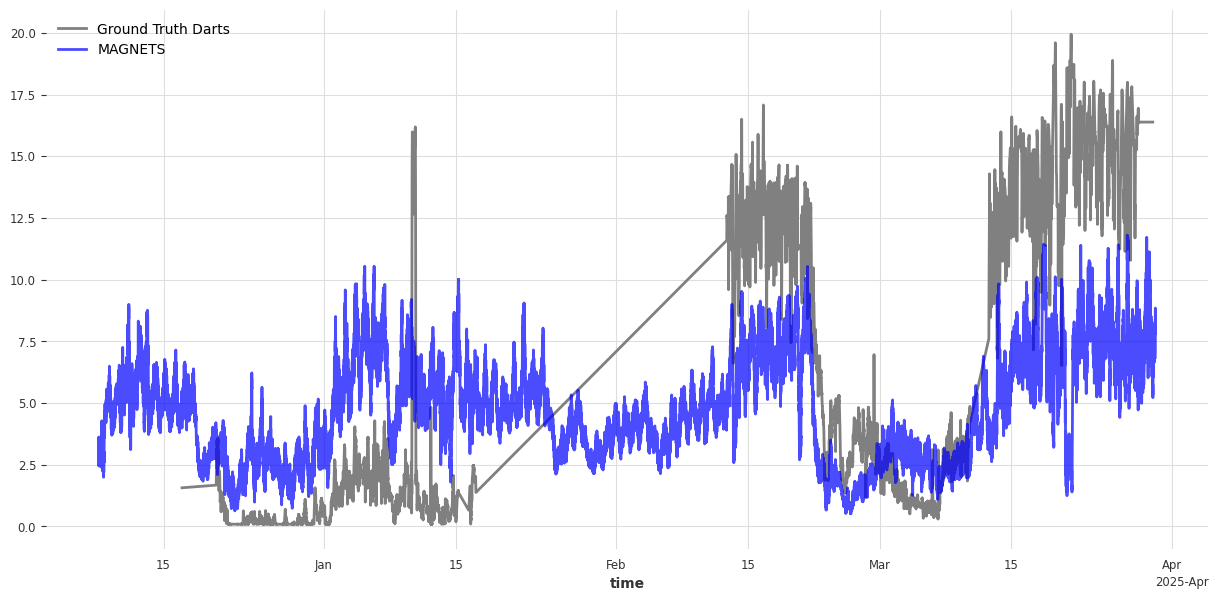

In [19]:
plot_preds_and_ground_truth(ground_truth1, nc_rnn1, nc_tcn1, nc_xgboost1, nc_elasticnet1, magnets_pred1)

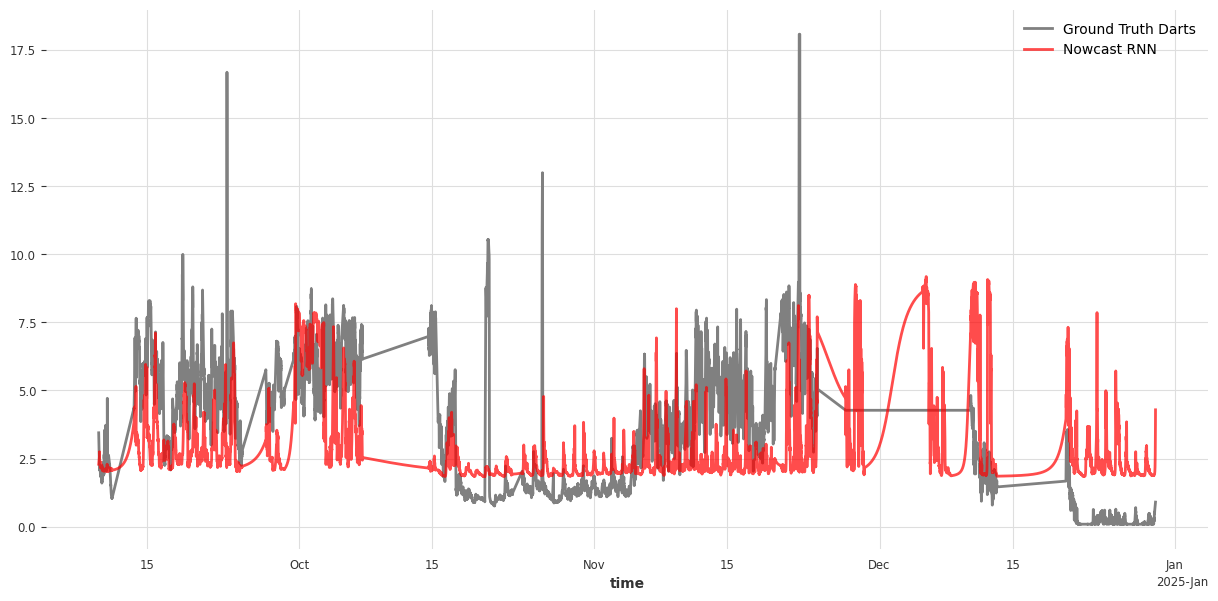

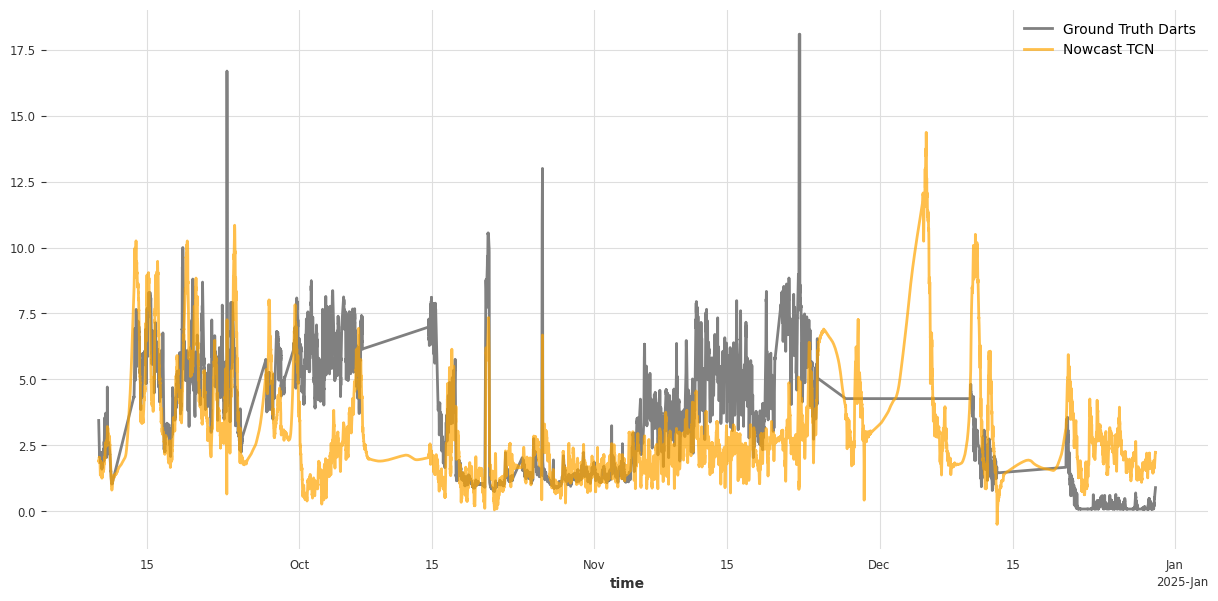

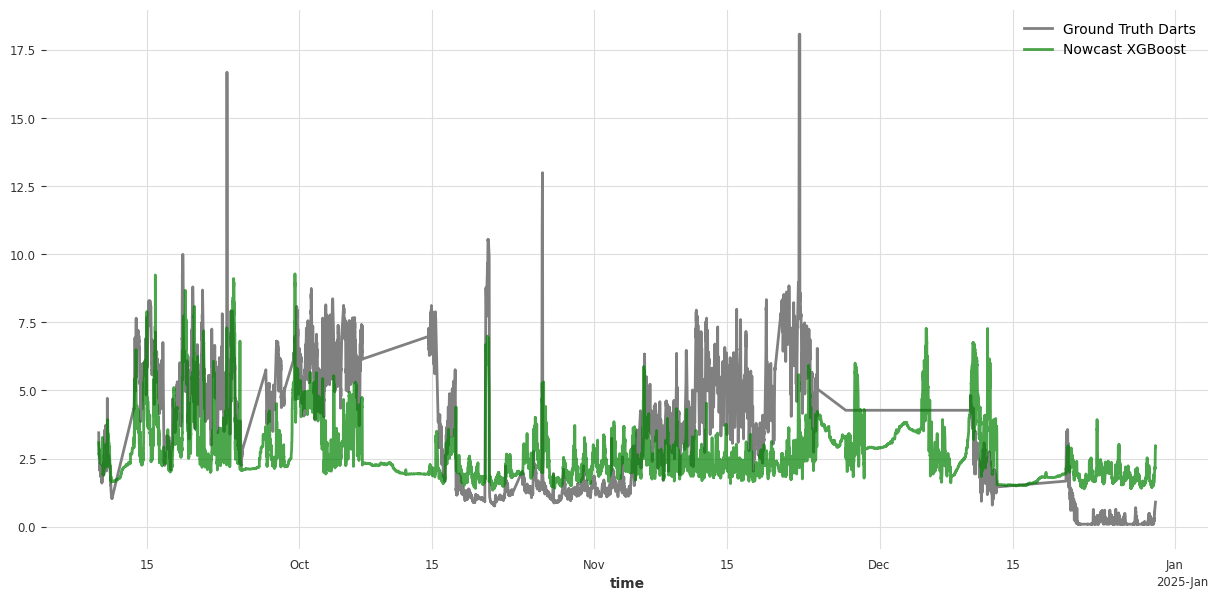

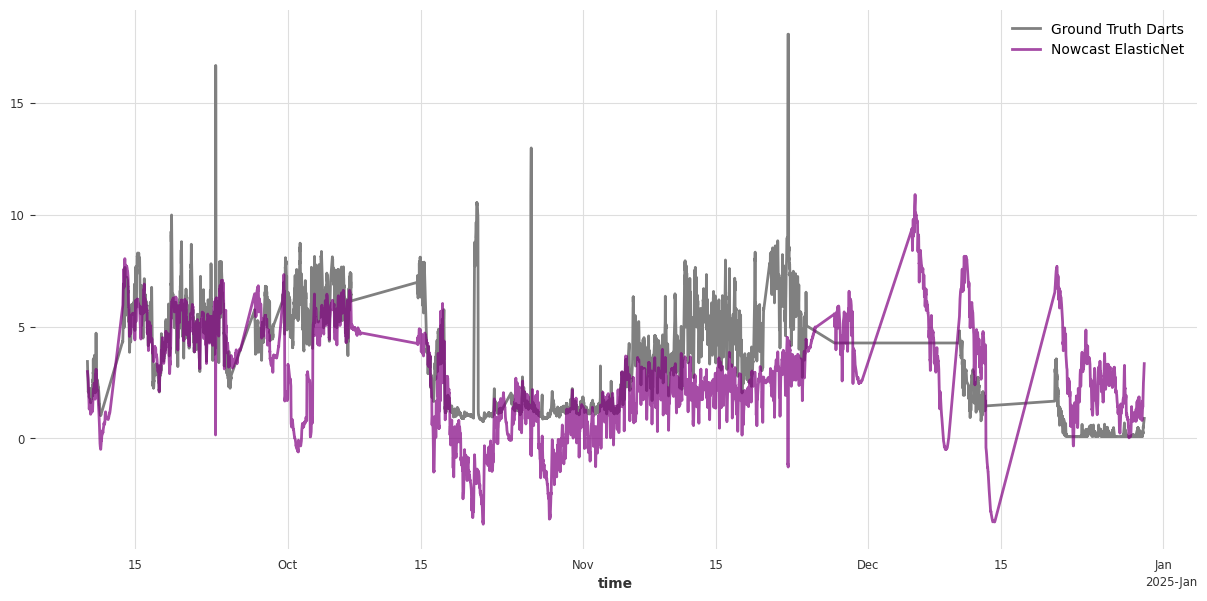

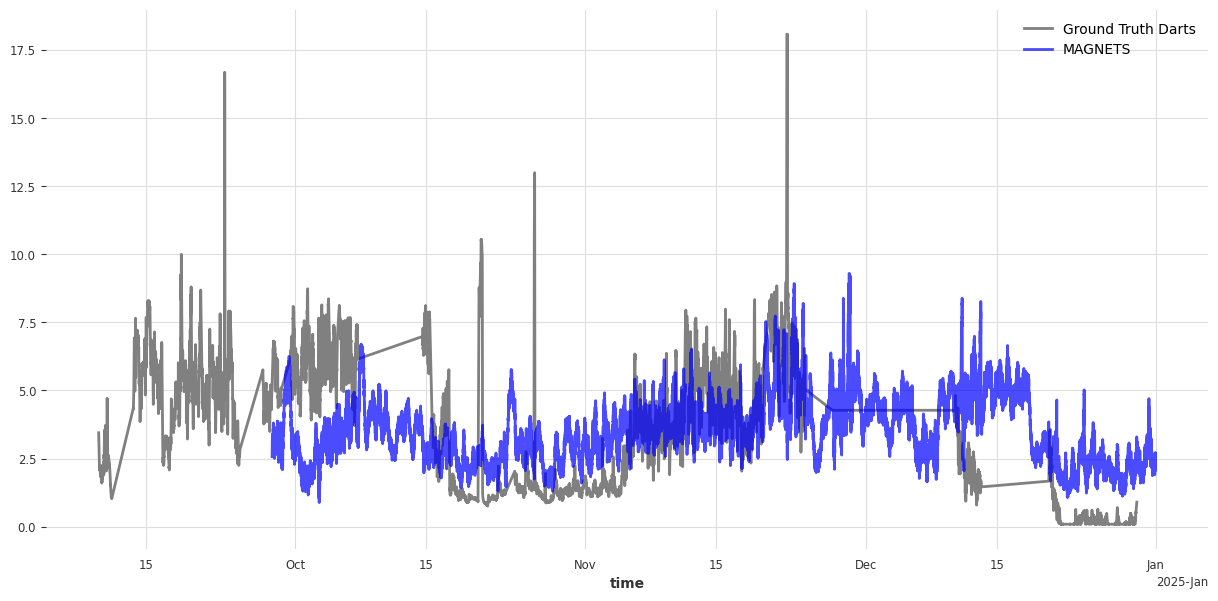

In [20]:
plot_preds_and_ground_truth(ground_truth2, nc_rnn2, nc_tcn2, nc_xgboost2, nc_elasticnet2, magnets_pred2)

In [22]:
def mse_comparison(ground_truth, nc_rnn, nc_tcn, nc_xgboost, nc_elasticnet, magnets_pred):
    mse_rnn = mean_squared_error(ground_truth.values(), nc_rnn.values())
    mse_tcn = mean_squared_error(ground_truth.values(), nc_tcn.values())
    mse_xgboost = mean_squared_error(ground_truth.values(), nc_xgboost.values())
    mse_elasticnet = mean_squared_error(ground_truth.values(), nc_elasticnet.values())

    aligned_magnets = magnets_pred.slice_intersect(ground_truth)
    aligned_gt = ground_truth.slice_intersect(magnets_pred)

    mse_magnets = mean_squared_error(aligned_gt.values(), aligned_magnets.values())

    print(f"MSE RNN: {mse_rnn:.4f}")
    print(f"MSE TCN: {mse_tcn:.4f}")
    print(f"MSE XGBoost: {mse_xgboost:.4f}")
    print(f"MSE ElasticNet: {mse_elasticnet:.4f}")
    print(f"MSE MAGNETS: {mse_magnets:.4f}")

In [25]:
print("Test period from December 2024 to March 2025:")
mse_comparison(ground_truth1, nc_rnn1, nc_tcn1, nc_xgboost1, nc_elasticnet1, magnets_pred1)

print("\n")

print("Test period from October to December 2024:")
mse_comparison(ground_truth2, nc_rnn2, nc_tcn2, nc_xgboost2, nc_elasticnet2, magnets_pred2)

Test period from December 2024 to March 2025:
MSE RNN: 18.1059
MSE TCN: 6.0615
MSE XGBoost: 17.3854
MSE ElasticNet: 19.6847
MSE MAGNETS: 23.3965


Test period from October to December 2024:
MSE RNN: 6.2062
MSE TCN: 6.7045
MSE XGBoost: 5.0869
MSE ElasticNet: 6.1262
MSE MAGNETS: 4.9766
